# Aprendizado supervisionado
**Implementação em Pytorch**

## Configuração de ambiente

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision.transforms import Compose

from tqdm.auto import tqdm

import transforms as T
from dataset import FWIDataset

/home/al.bianca.abreu/.conda/envs/deepfwi-tf/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


## Configuração dos dados

In [3]:
transform_data = Compose([
    T.LogTransform(k=1),
    T.MinMaxNormalize(
        T.log_transform(-61, k=1),
        T.log_transform(120, k=1)
    )
])

transform_label = Compose([
    T.MinMaxNormalize(2000, 6000)
])

In [4]:
train_dataset = FWIDataset(
    anno="split_files/flatvel_a_train.txt",
    preload=False,
    sample_ratio=1,
    file_size=500,
    transform_data=transform_data,
    transform_label=transform_label
)

In [5]:
val_dataset = FWIDataset(
    anno="split_files/flatvel_a_val.txt",
    preload=False,
    sample_ratio=1,
    file_size=500,
    transform_data=transform_data,
    transform_label=transform_label
)

In [6]:
print(f"Training samples : {len(train_dataset)}")
print(f"Validation samples      : {len(val_dataset)}")

Training samples : 24000
Validation samples      : 6000


```python
from torch.utils.data import random_split

# 90% treino, 10% validação
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Training samples  : {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples      : {len(test_dataset)}")

In [7]:
batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [8]:
data, label = train_dataset[0]

print(f"Data shape : {data.shape}")
print(f"Label shape: {label.shape}")

Data shape : torch.Size([5, 1000, 70])
Label shape: torch.Size([1, 70, 70])


In [9]:
sample_data, sample_label = train_dataset[0]

in_channels = sample_data.shape[0]
model_size = sample_label.shape[-2:]

print(f"Input channels : {in_channels}")
print(f"Output size    : {model_size}")

Input channels : 5
Output size    : torch.Size([70, 70])


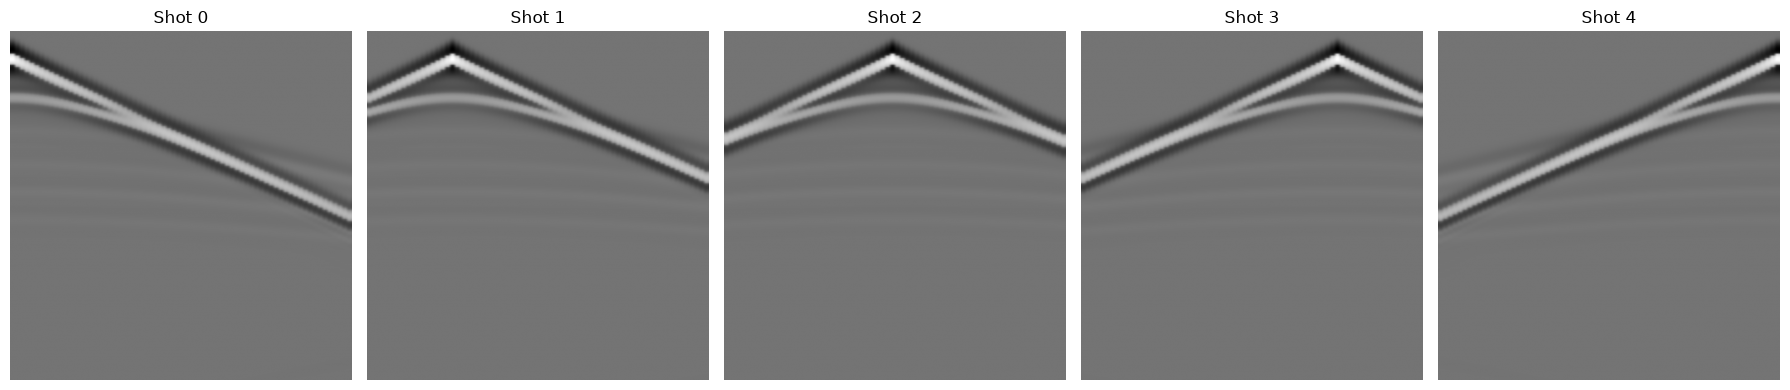

In [10]:
sample_data, sample_label = train_dataset[0]

fig, axes = plt.subplots(
    1,
    min(in_channels,6),
    figsize=(18,4)
)

for i in range(min(in_channels,6)):
    axes[i].imshow(sample_data[i], cmap="gray", aspect="auto")
    axes[i].set_title(f"Shot {i}")
    axes[i].axis("off")

plt.tight_layout()

(np.float64(-0.5), np.float64(69.5), np.float64(69.5), np.float64(-0.5))

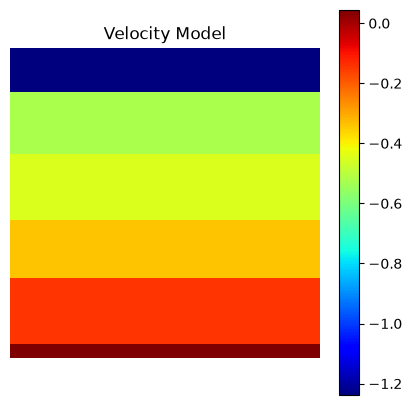

In [11]:
plt.figure(figsize=(5,5))

plt.imshow(
    sample_label.squeeze(),
    cmap="jet"
)

plt.colorbar()
plt.title("Velocity Model")
plt.axis("off")

## Arquitetura

In [12]:
import torch.nn.functional as F

In [13]:
class ConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        momentum=0.9,
        batchnorm=True
    ):

        super().__init__()

        bias = not batchnorm

        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                padding="same",
                bias=bias
            )
        ]

        if batchnorm:
            layers.append(
                nn.BatchNorm2d(
                    out_channels,
                    momentum=momentum,
                    eps=1e-3
                )
            )

        layers.append(nn.ReLU(inplace=True))

        layers.append(
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size,
                padding="same",
                bias=bias
            )
        )

        if batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))

        layers.append(nn.ReLU(inplace=True))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [ ]:
class UNet(nn.Module):

    def __init__(
        self,
        in_channels,
        output_channels=1,
        n_filters=16,
        dropout=0.2,
        momentum=0.9,
        batchnorm=True
    ):

        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.drop = nn.Dropout2d(dropout)

        # Encoder
        self.c1 = ConvBlock(
            in_channels,
            n_filters,
            kernel_size=6,
            momentum=momentum,
            batchnorm=batchnorm
        )

        self.c2 = ConvBlock(
            n_filters,
            n_filters*2,
            kernel_size=6,
            momentum=momentum,
            batchnorm=batchnorm
        )

        self.c3 = ConvBlock(
            n_filters*2,
            n_filters*4,
            kernel_size=6,
            momentum=momentum,
            batchnorm=batchnorm
        )

        self.c4 = ConvBlock(
            n_filters*4,
            n_filters*8,
            kernel_size=6,
            momentum=momentum,
            batchnorm=batchnorm
        )

        self.c5 = ConvBlock(
            n_filters*8,
            n_filters*16,
            kernel_size=6,
            momentum=momentum,
            batchnorm=batchnorm
        )

        # Decoder
        self.up6 = nn.ConvTranspose2d(
            n_filters*16,
            n_filters*8,
            kernel_size=3,
            stride=2,
            padding=1,
            output_padding=1
        )

        self.c6 = ConvBlock(
            n_filters*16,
            n_filters*8,
            kernel_size=3,
            momentum=momentum,
            batchnorm=batchnorm
        )

        self.up7 = nn.ConvTranspose2d(
            n_filters*8,
            n_filters*4,
            kernel_size=3,
            stride=2,
            padding=1,
            output_padding=1
        )

        self.c7 = ConvBlock(
            n_filters*8,
            n_filters*4,
            kernel_size=3,
            momentum=momentum,
            batchnorm=batchnorm
        )

        self.up8 = nn.ConvTranspose2d(
            n_filters*4,
            n_filters*2,
            kernel_size=3,
            stride=2,
            padding=1,
            output_padding=1
        )

        self.c8 = ConvBlock(
            n_filters*4,
            n_filters*2,
            kernel_size=3,
            momentum=momentum,
            batchnorm=batchnorm
        )

        self.up9 = nn.ConvTranspose2d(
            n_filters*2,
            n_filters,
            kernel_size=3,
            stride=2,
            padding=1,
            output_padding=1
        )

        self.c9 = ConvBlock(
            n_filters*2,
            n_filters,
            kernel_size=3,
            momentum=momentum,
            batchnorm=batchnorm
        )

        self.out = nn.Conv2d(
            n_filters,
            output_channels,
            kernel_size=1
        )

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = F.interpolate(
            u6,
            size=c4.shape[2:],
            mode="bilinear",
            align_corners=False
        )
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = F.interpolate(
            u7,
            size=c3.shape[2:],
            mode="bilinear",
            align_corners=False
        )
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = F.interpolate(
            u8,
            size=c2.shape[2:],
            mode="bilinear",
            align_corners=False
        )
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = F.interpolate(
            u9,
            size=c1.shape[2:],
            mode="bilinear",
            align_corners=False
        )
        u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

## Parâmetros

In [15]:
from pytorch_msssim import ssim

coef = 0.5

def ssim_loss(y_pred, y_true):
    return 1 - ssim(
        y_pred,
        y_true,
        data_range=1.0,
        size_average=True
    )


def ssim_rmse_loss(y_pred, y_true):

    ssim_component = 1 - ssim(
        y_pred,
        y_true,
        data_range=1.0,
        size_average=True
    )

    mse_component = torch.mean((y_pred - y_true) ** 2)

    return coef * ssim_component + (1 - coef) * mse_component

In [16]:
BATCH = 8
EPOCHS = 100

learning_rate = 1e-4
weight_decay = 2e-4

model = UNet(
    in_channels=in_channels
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

### Treinamento

In [ ]:
from tqdm.auto import tqdm

EPOCHS = 100
best_val_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(EPOCHS):

    ##########################
    # Treinamento
    ##########################
    model.train()
    train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}",
        leave=False
    )

    for batch_data, batch_labels in train_bar:

        batch_data = batch_data.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        outputs = model(batch_data)

        loss = criterion(outputs, batch_labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_data.size(0)

        train_bar.set_postfix(
            batch_loss=f"{loss.item():.5f}",
            avg_loss=f"{train_loss / ((train_bar.n + 1) * batch_data.size(0)):.5f}"
        )

    train_loss /= len(train_loader.dataset)

    ##########################
    # Validação
    ##########################
    model.eval()
    val_loss = 0.0

    with torch.no_grad():

        val_bar = tqdm(
            val_loader,
            desc="Validation",
            leave=False
        )

        for batch_data, batch_labels in val_bar:

            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            print(batch_data.shape)

            outputs = model(batch_data)

            loss = criterion(outputs, batch_labels)

            val_loss += loss.item() * batch_data.size(0)

            val_bar.set_postfix(
                batch_loss=f"{loss.item():.5f}",
                avg_loss=f"{val_loss / ((val_bar.n + 1) * batch_data.size(0)):.5f}"
            )

    val_loss /= len(val_loader.dataset)

    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.5f} | "
        f"Val Loss: {val_loss:.5f}"
    )

    if val_loss < best_val_loss:
        print(
            f"Validation loss improved "
            f"({best_val_loss:.5f} → {val_loss:.5f}), saving model..."
        )

        best_val_loss = val_loss
        torch.save(model.state_dict(), "model_teste01_pytorch.pt")
        patience_counter = 0

    else:
        patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

### Melhor modelo

In [ ]:
model.load_state_dict(
    torch.load(best_model)
)

model.eval()

In [ ]:
plt.figure(figsize=(8,8))

plt.plot(train_history, label="loss")

plt.plot(val_history, label="val_loss")

best_epoch = np.argmin(val_history)

plt.scatter(
    best_epoch,
    val_history[best_epoch],
    marker="x",
    s=100,
    label="best model"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()